# Neural Network Health Condition Classifier

This notebook trains a feed-forward neural network for multiclass `health_condition` prediction. It uses the leakage-safe numeric train/validation/test feature files and relies on neural-network regularization instead of hard feature selection.

## 1. Load Numeric Features

In [1]:
import os
import random

import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


In [2]:
ID_COL = "id"
TARGET_COL = "health_condition"

train_path = "data/train_split_features_numeric.csv"
val_path = "data/val_split_features_numeric.csv"
test_path = "data/test_features_numeric.csv"
sample_submission_path = "data/sample_submission.csv"

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

print("train:", train_df.shape)
print("validation:", val_df.shape)
print("test:", test_df.shape)
print("sample submission:", sample_submission.shape)

train: (552070, 73)
validation: (138018, 73)
test: (295753, 72)
sample submission: (295753, 2)


## 2. Prepare X/y/test

`id` is kept only for submission and is not used as a model feature. `health_condition` is the target and is not present in test.

In [3]:
feature_cols = [col for col in train_df.columns if col not in [ID_COL, TARGET_COL]]

train_feature_cols_without_target = [col for col in train_df.columns if col != TARGET_COL]
assert train_feature_cols_without_target == list(val_df.drop(columns=[TARGET_COL]).columns)
assert train_feature_cols_without_target == list(test_df.columns)

X_train_raw = train_df[feature_cols].copy()
y_train_raw = train_df[TARGET_COL].copy()
X_val_raw = val_df[feature_cols].copy()
y_val_raw = val_df[TARGET_COL].copy()
X_test_raw = test_df[feature_cols].copy()
test_ids = test_df[ID_COL].copy()

print("number of model features:", len(feature_cols))
print("X_train_raw:", X_train_raw.shape)
print("X_val_raw:", X_val_raw.shape)
print("X_test_raw:", X_test_raw.shape)
print("missing train values:", int(X_train_raw.isna().sum().sum()))
print("missing val values:", int(X_val_raw.isna().sum().sum()))
print("missing test values:", int(X_test_raw.isna().sum().sum()))

number of model features: 71
X_train_raw: (552070, 71)
X_val_raw: (138018, 71)
X_test_raw: (295753, 71)
missing train values: 0
missing val values: 0
missing test values: 0


In [4]:
target_distribution = pd.DataFrame({
    "train_count": y_train_raw.value_counts(),
    "train_pct": y_train_raw.value_counts(normalize=True).mul(100),
    "val_count": y_val_raw.value_counts(),
    "val_pct": y_val_raw.value_counts(normalize=True).mul(100),
}).round(2)

target_distribution

,train_count,train_pct,val_count,val_pct
at-risk,474049,85.87,118512,85.87
unhealthy,46179,8.36,11545,8.36
fit,31842,5.77,7961,5.77


## 3. Target Encoding

The network uses integer target labels with sparse categorical cross-entropy. Label order is learned from train and reused for validation/test predictions.

In [5]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_val = label_encoder.transform(y_val_raw)
class_names = label_encoder.classes_
num_classes = len(class_names)

label_mapping = pd.DataFrame({
    "class_id": range(num_classes),
    "health_condition": class_names,
})
label_mapping

,class_id,health_condition
0,0,at-risk
1,1,fit
2,2,unhealthy


## 4. Train/Validation Split

The split was already created in `data_read.ipynb` using stratification. This notebook does not split again; it loads the fixed split files so all preprocessing and modeling stay reproducible.

In [6]:
split_summary = pd.DataFrame([
    {"dataset": "train_split", "rows": len(train_df), "features": X_train_raw.shape[1]},
    {"dataset": "val_split", "rows": len(val_df), "features": X_val_raw.shape[1]},
    {"dataset": "test", "rows": len(test_df), "features": X_test_raw.shape[1]},
])

split_summary

,dataset,rows,features
0,train_split,552070,71
1,val_split,138018,71
2,test,295753,71


## 5. Scaling

Neural networks are sensitive to feature scale. `StandardScaler` is fit on the training split only, then applied to validation and test.

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype("float32")
X_val = scaler.transform(X_val_raw).astype("float32")
X_test = scaler.transform(X_test_raw).astype("float32")

print("scaled train mean range:", float(X_train.mean(axis=0).min()), float(X_train.mean(axis=0).max()))
print("scaled train std range:", float(X_train.std(axis=0).min()), float(X_train.std(axis=0).max()))

scaled train mean range: -4.733908909315687e-08 5.032067207366708e-08
scaled train std range: 0.0 1.0000001192092896


## 6. Feature Selection Experiments

Feature selection strategy: **Option C, no hard feature removal**.

Because the dataset has only around 70 numeric model features, we keep all features and let the neural network handle feature usefulness through regularization:

- L2 weight decay
- Dropout
- Batch normalization
- Early stopping
- Class weights for imbalance

This avoids throwing away potentially useful engineered signals before the neural net sees them.

In [8]:
selected_feature_cols = feature_cols.copy()
X_train_selected = X_train
X_val_selected = X_val
X_test_selected = X_test

feature_selection_report = pd.DataFrame([
    {
        "strategy": "regularized_neural_network_no_hard_selection",
        "selected_feature_count": len(selected_feature_cols),
        "removed_feature_count": 0,
        "regularization": "L2 + dropout + batchnorm + early stopping",
    }
])

feature_selection_report

,strategy,selected_feature_count,removed_feature_count,regularization
0,regularized_neural_network_no_hard_selection,71,0,L2 + dropout + batchnorm + early stopping


## 7. Neural Network Training

Backpropagation is performed by Keras during `model.fit`: forward pass, loss calculation, gradient backpropagation, and Adam weight updates.

Class imbalance is handled with `class_weight`, computed from the train split only.

In [9]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train,
)
class_weight = {class_id: weight for class_id, weight in enumerate(class_weights_array)}

class_weight_report = pd.DataFrame({
    "class_id": np.arange(num_classes),
    "health_condition": class_names,
    "class_weight": class_weights_array,
    "train_count": np.bincount(y_train, minlength=num_classes),
})

class_weight_report

,class_id,health_condition,class_weight,train_count
0,0,at-risk,0.388195,474049
1,1,fit,5.779264,31842
2,2,unhealthy,3.985000,46179


In [10]:
def build_model(input_dim, num_classes, learning_rate=1e-3, l2_strength=1e-4):
    regularizer = tf.keras.regularizers.l2(l2_strength)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, kernel_regularizer=regularizer),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.30),

        tf.keras.layers.Dense(64, kernel_regularizer=regularizer),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.20),

        tf.keras.layers.Dense(32, kernel_regularizer=regularizer),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.10),

        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


BATCH_SIZE = 2048
MAX_EPOCHS = 50

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1,
    ),
]

model = build_model(X_train_selected.shape[1], num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,547 (80.26 KB)

 Trainable params: 20,099 (78.51 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
history = model.fit(
    X_train_selected,
    y_train,
    validation_data=(X_val_selected, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

history_df = pd.DataFrame(history.history)
best_epoch = int(history_df["val_loss"].idxmin() + 1)
print("best epoch by validation loss:", best_epoch)
history_df.tail()

Epoch 1/50


  1/270 ━━━━━━━━━━━━━━━━━━━━ 2:58 663ms/step - accuracy: 0.2144 - loss: 1.3237

 11/270 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2445 - loss: 1.1593    

 21/270 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2734 - loss: 1.0452

 33/270 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3077 - loss: 0.9560

...

270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8650 - loss: 0.2592 - val_accuracy: 0.8666 - val_loss: 0.2756 - learning_rate: 1.2500e-04


Epoch 17: early stopping


Restoring model weights from the end of the best epoch: 12.


best epoch by validation loss: 12


,accuracy,loss,val_accuracy,val_loss,learning_rate
12,0.865850,0.265675,0.868459,0.277398,0.000500
13,0.865577,0.264466,0.865162,0.277561,0.000500
14,0.865052,0.261839,0.865561,0.276206,0.000250
15,0.866198,0.260385,0.862960,0.280362,0.000250
16,0.865301,0.258644,0.866626,0.275615,0.000125


## 8. Evaluation

In [12]:
val_pred_proba = model.predict(X_val_selected, batch_size=BATCH_SIZE, verbose=0)
val_pred = val_pred_proba.argmax(axis=1)
val_pred_labels = label_encoder.inverse_transform(val_pred)

val_accuracy = accuracy_score(y_val, val_pred)
val_macro_f1 = f1_score(y_val, val_pred, average="macro")
val_weighted_f1 = f1_score(y_val, val_pred, average="weighted")

evaluation_summary = pd.DataFrame([
    {
        "validation_accuracy": val_accuracy,
        "validation_macro_f1": val_macro_f1,
        "validation_weighted_f1": val_weighted_f1,
        "best_epoch": best_epoch,
        "feature_count": len(selected_feature_cols),
    }
])

evaluation_summary

,validation_accuracy,validation_macro_f1,validation_weighted_f1,best_epoch,feature_count
0,0.870176,0.748029,0.883851,12,71


In [13]:
print(classification_report(y_val_raw, val_pred_labels, labels=class_names))

              precision    recall  f1-score   support

     at-risk       0.99      0.86      0.92    118512
         fit       0.50      0.92      0.64      7961
   unhealthy       0.54      0.91      0.68     11545

    accuracy                           0.87    138018
   macro avg       0.67      0.90      0.75    138018
weighted avg       0.92      0.87      0.88    138018



In [14]:
confusion = pd.DataFrame(
    confusion_matrix(y_val_raw, val_pred_labels, labels=class_names),
    index=[f"actual_{label}" for label in class_names],
    columns=[f"pred_{label}" for label in class_names],
)

confusion

,pred_at-risk,pred_fit,pred_unhealthy
actual_at-risk,102232,7411,8869
actual_fit,594,7318,49
actual_unhealthy,956,39,10550


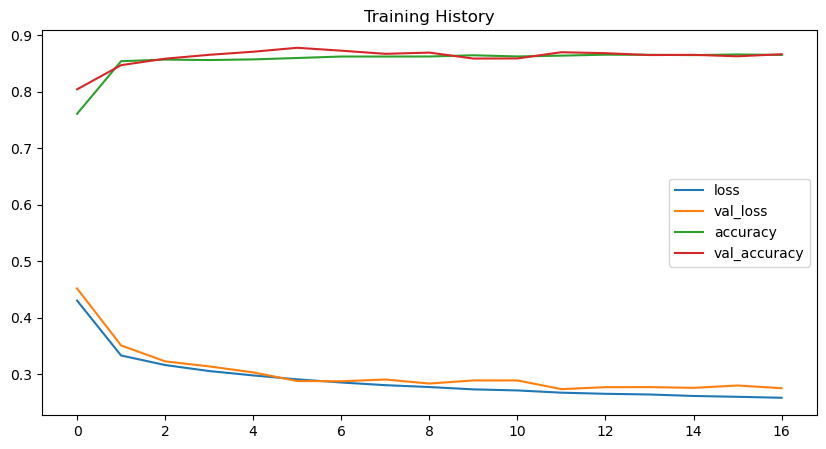

In [15]:
history_df[["loss", "val_loss", "accuracy", "val_accuracy"]].plot(figsize=(10, 5), title="Training History");

## 9. Final Full-Data Training

After validation, combine train and validation splits, refit the scaler on the combined labeled data, and train a final model for the selected number of epochs.

This uses all labeled rows for the final model. The real test file is still never used for fitting.

In [16]:
full_train_df = pd.concat([train_df, val_df], ignore_index=True)
X_full_raw = full_train_df[feature_cols].copy()
y_full_raw = full_train_df[TARGET_COL].copy()
y_full = label_encoder.transform(y_full_raw)

final_scaler = StandardScaler()
X_full = final_scaler.fit_transform(X_full_raw).astype("float32")
X_test_final = final_scaler.transform(X_test_raw).astype("float32")

final_class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_full,
)
final_class_weight = {class_id: weight for class_id, weight in enumerate(final_class_weights_array)}

final_epochs = max(1, best_epoch)
final_model = build_model(X_full.shape[1], num_classes)

print("full training rows:", X_full.shape[0])
print("final epochs:", final_epochs)
print("final class weights:", final_class_weight)

full training rows: 690088
final epochs: 12
final class weights: {0: 0.38819519565636845, 1: 5.779195873007898, 2: 3.9849860254544613}


In [17]:
final_history = final_model.fit(
    X_full,
    y_full,
    epochs=final_epochs,
    batch_size=BATCH_SIZE,
    class_weight=final_class_weight,
    verbose=1,
)

final_history_df = pd.DataFrame(final_history.history)
final_history_df.tail()

Epoch 1/12


  1/337 ━━━━━━━━━━━━━━━━━━━━ 3:41 658ms/step - accuracy: 0.3413 - loss: 1.4369

 11/337 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3762 - loss: 1.2223    

 21/337 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4015 - loss: 1.0903

 31/337 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4255 - loss: 1.0019

...

314/337 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8614 - loss: 0.2695

322/337 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8614 - loss: 0.2694

330/337 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8614 - loss: 0.2693

337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8614 - loss: 0.2692


,accuracy,loss
7,0.861777,0.275391
8,0.861678,0.271492
9,0.861739,0.269660
10,0.860553,0.266602
11,0.861234,0.265708


## 10. Test Prediction + Submission File

In [18]:
test_pred_proba = final_model.predict(X_test_final, batch_size=BATCH_SIZE, verbose=0)
test_pred = test_pred_proba.argmax(axis=1)
test_pred_labels = label_encoder.inverse_transform(test_pred)

submission = sample_submission.copy()
submission[ID_COL] = test_ids.values
submission[TARGET_COL] = test_pred_labels

submission_path = "data/submission_neural_network.csv"
submission.to_csv(submission_path, index=False)

print("saved:", submission_path, submission.shape)
submission[TARGET_COL].value_counts(normalize=True).mul(100).round(2)

saved: data/submission_neural_network.csv (295753, 2)


at-risk      73.12
unhealthy    14.96
fit          11.92
Name: health_condition, dtype: float64

In [19]:
submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
